# Optimizing Drift Detectors via Leave-One-Dataset-Out Cross-Validation

Drift detectors have hyperparameters that control sensitivity. Defaults work
well in some situations but poorly in others. This notebook shows a
standardized protocol for tuning those hyperparameters:

1. Build several streams with known drift locations.
2. Train a classifier (Hoeffding Tree) on each stream, producing an error
   signal.
3. Run a candidate detector on each error signal and score it with
   `EvaluateDriftDetector`.
4. Use *leave-one-dataset-out cross-validation*: optimize on all but one
   dataset, then evaluate on the held-out one.

The evaluation metric is **F1**, which balances precision and recall of
drift detections.

**Reference:** [1] Cerqueira, V., Gomes, H. M., Heyden, M., Pfahringer, B., & Bifet, A. (2026). *A Framework for Evaluating and Benchmarking Concept Drift Detection Methods.* ACM SIGKDD Conference on Knowledge Discovery and Data Mining.

---

*More information about CapyMOA can be found at* https://www.capymoa.org.

**last update on 03/09/2026**

In [40]:
# This cell is hidden on capymoa.org. See docs/contributing/docs.rst
from util.nbmock import is_nb_fast

In [41]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import uniform, randint
from sklearn.model_selection import ParameterSampler  # for random search

from capymoa.classifier import HoeffdingTree
from capymoa.drift.detectors import SEED
from capymoa.drift.eval_detector import EvaluateDriftDetector
from capymoa.evaluation import prequential_evaluation
from capymoa.stream.drift import AbruptDrift, Concept, DriftStream
from capymoa.stream.generator import (
    SEA,
    AgrawalGenerator,
    RandomTreeGenerator,
    STAGGERGenerator,
)

## 1. Benchmark Streams

We create four synthetic streams as example, each with one abrupt drift. The streams use different generators so that the optimization is not tied to a single
data source. Each stream contains 20 000 instances with a drift at
instance 10 000. See reference [1] for realistic examples using real-world datasets with injected drifts. 

In [42]:
MAX_INSTANCES = 20_000
DRIFT_AT = 10_000
MAX_DELAY = 500
N_SAMPLES = 20
RANDOM_STATE = 42

In [43]:
# This cell is hidden on capymoa.org. See docs/contributing/docs.rst
if is_nb_fast():
    MAX_INSTANCES = 400
    DRIFT_AT = 200
    MAX_DELAY = 50
    N_SAMPLES = 3

In [44]:
streams = {
    "SEA": DriftStream(
        stream=[
            Concept(SEA(function=1), num_instances=DRIFT_AT),
            AbruptDrift(),
            Concept(SEA(function=3), num_instances=DRIFT_AT),
        ]
    ),
    "STAGGER": DriftStream(
        stream=[
            Concept(
                STAGGERGenerator(classification_function=1),
                num_instances=DRIFT_AT,
            ),
            AbruptDrift(),
            Concept(
                STAGGERGenerator(classification_function=3),
                num_instances=DRIFT_AT,
            ),
        ]
    ),
    "RandomTree": DriftStream(
        stream=[
            Concept(RandomTreeGenerator(tree_random_seed=1), num_instances=DRIFT_AT),
            AbruptDrift(),
            Concept(RandomTreeGenerator(tree_random_seed=42), num_instances=DRIFT_AT),
        ]
    ),
    "Agrawal": DriftStream(
        stream=[
            Concept(
                AgrawalGenerator(classification_function=1, instance_random_seed=1),
                num_instances=DRIFT_AT,
            ),
            AbruptDrift(),
            Concept(
                AgrawalGenerator(classification_function=4, instance_random_seed=42),
                num_instances=DRIFT_AT,
            ),
        ]
    ),
}

for name, stream in streams.items():
    drifts = stream.get_drifts()
    positions = [d.position for d in drifts]
    print(f"{name:>12s}: drift(s) at {positions}")

         SEA: drift(s) at [10000]
     STAGGER: drift(s) at [10000]
  RandomTree: drift(s) at [10000]
     Agrawal: drift(s) at [10000]


## 2. Producing the Error Signal

For each stream we run a Hoeffding Tree in the prequential
(test-then-train) setting. We store the predictions and ground truth so
that we can compute a binary error signal: 1 when the classifier is wrong,
0 when it is right. This error signal is what the drift detector will
monitor.

In [45]:
def build_error_signal(stream, max_instances):
    """Run a Hoeffding Tree on `stream` and return a binary error signal."""
    learner = HoeffdingTree(schema=stream.get_schema())
    results = prequential_evaluation(
        stream,
        learner,
        max_instances=max_instances,
        store_predictions=True,
        store_y=True,
    )
    y_true = results.ground_truth_y()
    y_pred = results.predictions()
    errors = (y_true != y_pred).astype(float)
    return errors


error_signals = {}
for name, stream in streams.items():
    error_signals[name] = build_error_signal(stream, MAX_INSTANCES)
    print(
        f"{name:>12s}: {len(error_signals[name])} instances, "
        f"error rate = {error_signals[name].mean():.3f}"
    )

         SEA: 20000 instances, error rate = 0.132
     STAGGER: 20000 instances, error rate = 0.027
  RandomTree: 20000 instances, error rate = 0.301
     Agrawal: 20000 instances, error rate = 0.196


## 3. Defining the Optimization Search Space

We use **SEED** (Streaming Ensemble Algorithm for Drift detection) as the
example detector. It has several key parameters:

- `delta`: significance level for the statistical test (default 0.05)
- `block_size`: size of data blocks for compression (default 32)
- `epsilon_prime`: tolerance parameter for drift detection (default 0.01)

Lower `delta` and `epsilon_prime` values make the detector more sensitive
(more alarms); higher `block_size` gives smoother but slower detection.

We use sklearn's `ParameterSampler` for random search over both continuous
and discrete distributions.

In [46]:
param_distributions = {
    "delta": uniform(loc=0.01, scale=0.19),
    "block_size": randint(32, 65),
    "epsilon_prime": np.linspace(0.0025, 0.01, 11),
}

sampler = ParameterSampler(
    param_distributions, n_iter=N_SAMPLES, random_state=RANDOM_STATE
)
param_configs = list(sampler)

# Show a few sampled configurations
print(f"Sampled {len(param_configs)} configurations:")
for i, cfg in enumerate(param_configs[:5]):
    print(
        f"  {i + 1}. delta={cfg['delta']:.4f}, "
        f"block_size={cfg['block_size']}, "
        f"epsilon_prime={cfg['epsilon_prime']:.4f}"
    )
print("  ...")

Sampled 20 configurations:
  1. delta=0.0449, block_size=60, epsilon_prime=0.0077
  2. delta=0.0396, block_size=52, epsilon_prime=0.0040
  3. delta=0.0210, block_size=54, epsilon_prime=0.0077
  4. delta=0.1337, block_size=55, epsilon_prime=0.0055
  5. delta=0.1472, block_size=33, epsilon_prime=0.0063
  ...


## 4. Scoring a Single Configuration

Given an error signal, a set of true drift positions, and a candidate
parameter configuration, we run SEED and compute the F1 score.

In [47]:
def run_detector(error_signal, params):
    """Run SEED with given parameters on an error signal and return the
    list of detection indices."""
    detector = SEED(
        delta=params["delta"],
        block_size=params["block_size"],
        epsilon_prime=params["epsilon_prime"],
    )
    for val in error_signal:
        detector.add_element(val)
    return detector.detection_index


def evaluate_detector(error_signal, true_positions, params, max_delay):
    """Run SEED with `params` and return the metrics."""
    preds = run_detector(error_signal, params)

    evaluator = EvaluateDriftDetector(max_delay=max_delay)
    metrics = evaluator.calc_performance(
        trues=np.array(true_positions),
        preds=preds,
        tot_n_instances=len(error_signal),
    )
    return metrics

## 5. Scoring All Configurations on Every Dataset

Before doing the cross-validation split, we first evaluate every sampled
configuration on every dataset so that the full table of results is
available.

In [48]:
dataset_names = list(streams.keys())

# Build a dict: scores[dataset_name][config_idx] = F1
scores = {}
for name in dataset_names:
    stream = streams[name]
    true_positions = [d.position for d in stream.get_drifts()]
    scores[name] = {}
    for idx, params in enumerate(param_configs):
        metrics = evaluate_detector(
            error_signals[name], true_positions, params, MAX_DELAY
        )
        scores[name][idx] = metrics.f1

# Create a DataFrame with config details as index
config_labels = [
    f"d={p['delta']:.3f}, bs={p['block_size']}, ep={p['epsilon_prime']:.4f}"
    for p in param_configs
]
scores_df = pd.DataFrame(scores)
scores_df.index = config_labels
scores_df.index.name = "config"
scores_df

,SEA,STAGGER,RandomTree,Agrawal
config,,,,
"d=0.045, bs=60, ep=0.0077",0.000000,0.545455,0.285714,0.285714
"d=0.040, bs=52, ep=0.0040",0.000000,0.333333,0.444444,0.285714
"d=0.021, bs=54, ep=0.0077",0.000000,0.285714,0.285714,0.333333
"d=0.134, bs=55, ep=0.0055",0.285714,0.444444,0.285714,0.222222
"d=0.147, bs=33, ep=0.0063",0.250000,0.500000,0.285714,0.250000
"d=0.045, bs=33, ep=0.0055",0.000000,0.571429,0.285714,0.250000
"d=0.068, bs=64, ep=0.0063",0.000000,0.600000,0.250000,0.285714
"d=0.065, bs=56, ep=0.0100",0.000000,0.600000,0.285714,0.285714
"d=0.195, bs=59, ep=0.0040",0.200000,0.444444,0.250000,0.250000


## 6. Leave-One-Dataset-Out Cross-Validation

For each held-out dataset:

1. **Optimize**: pick the configuration that maximizes the mean F1 over
   the remaining datasets.
2. **Evaluate**: apply that configuration to the held-out dataset and
   record the F1.

This simulates the real-world scenario where the detector is tuned on
available data and then deployed on a new, unseen stream.

In [49]:
cv_results = []

for held_out in dataset_names:
    train_datasets = [d for d in dataset_names if d != held_out]

    # Mean F1 across training datasets for each config
    mean_f1_per_config = {}
    for idx in range(len(param_configs)):
        f1_values = [scores[d][idx] for d in train_datasets]
        mean_f1_per_config[idx] = np.mean(f1_values)

    # Best config on training datasets
    best_idx = max(mean_f1_per_config, key=mean_f1_per_config.get)
    best_params = param_configs[best_idx]
    best_train_f1 = mean_f1_per_config[best_idx]

    # Evaluate best config on the held-out dataset
    test_f1 = scores[held_out][best_idx]

    cv_results.append(
        {
            "held_out": held_out,
            "best_delta": round(best_params["delta"], 4),
            "best_block_size": best_params["block_size"],
            "best_epsilon_prime": round(best_params["epsilon_prime"], 4),
            "mean_train_f1": round(best_train_f1, 4),
            "test_f1": round(test_f1, 4),
            "_best_idx": best_idx,  # keep for later use
        }
    )

    print(
        f"Held out: {held_out:>12s} | "
        f"Best: delta={best_params['delta']:.4f}, bs={best_params['block_size']}, "
        f"ep={best_params['epsilon_prime']:.4f} | "
        f"Train F1 = {best_train_f1:.4f} | "
        f"Test F1 = {test_f1:.4f}"
    )

cv_df = pd.DataFrame(cv_results).drop(columns=["_best_idx"])
cv_df

Held out:          SEA | Best: delta=0.0451, bs=35, ep=0.0033 | Train F1 = 0.4434 | Test F1 = 0.0000
Held out:      STAGGER | Best: delta=0.0558, bs=51, ep=0.0070 | Train F1 = 0.3016 | Test F1 = 0.3333
Held out:   RandomTree | Best: delta=0.0955, bs=57, ep=0.0092 | Train F1 = 0.4063 | Test F1 = 0.2857
Held out:      Agrawal | Best: delta=0.0955, bs=57, ep=0.0092 | Train F1 = 0.4063 | Test F1 = 0.2857


,held_out,best_delta,best_block_size,best_epsilon_prime,mean_train_f1,test_f1
0,SEA,0.0451,35,0.0032,0.4434,0.0000
1,STAGGER,0.0558,51,0.0070,0.3016,0.3333
2,RandomTree,0.0955,57,0.0092,0.4063,0.2857
3,Agrawal,0.0955,57,0.0092,0.4063,0.2857


The plot below shows how F1 varies across sampled configurations for each
dataset. Configurations are sorted by their mean F1 across all datasets.

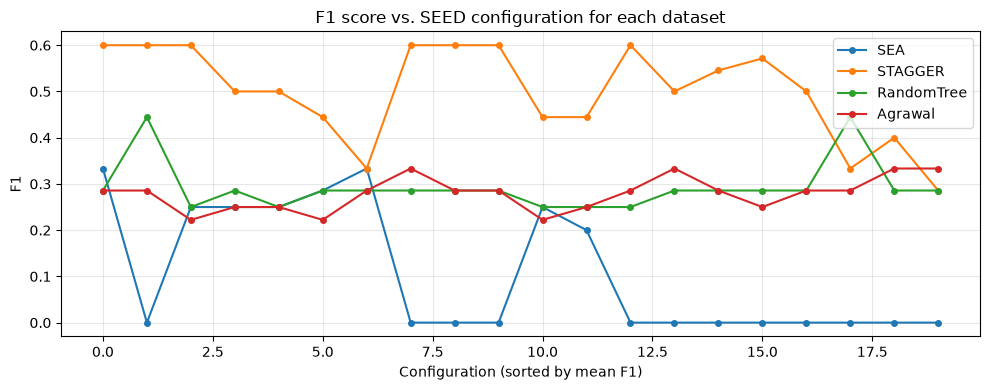

In [50]:
# Sort configurations by mean F1 across datasets
mean_f1_per_config = [
    np.mean([scores[d][idx] for d in dataset_names])
    for idx in range(len(param_configs))
]
sorted_indices = np.argsort(mean_f1_per_config)[::-1]

fig, ax = plt.subplots(figsize=(10, 4))
for name in dataset_names:
    f1_values = [scores[name][idx] for idx in sorted_indices]
    ax.plot(range(len(param_configs)), f1_values, marker="o", markersize=4, label=name)

ax.set_xlabel("Configuration (sorted by mean F1)")
ax.set_ylabel("F1")
ax.set_title("F1 score vs. SEED configuration for each dataset")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Applying the Optimized Detector to a Held-Out Dataset

As a concrete example we pick the last fold -- the one where `Agrawal`
was held out -- and show the full detection trace on it.

In [51]:
# Use the last dataset as an example
example_fold = cv_results[-1]
held_out_name = example_fold["held_out"]
best_params = {
    "delta": example_fold["best_delta"],
    "block_size": example_fold["best_block_size"],
    "epsilon_prime": example_fold["best_epsilon_prime"],
}

print(f"Held-out dataset      : {held_out_name}")
print(f"Optimized delta       : {best_params['delta']:.4f}")
print(f"Optimized block_size  : {best_params['block_size']}")
print(f"Optimized epsilon_prime: {best_params['epsilon_prime']:.4f}")
print(f"Test F1               : {example_fold['test_f1']}")

# Run the optimized detector
detections = run_detector(error_signals[held_out_name], best_params)
true_positions = [d.position for d in streams[held_out_name].get_drifts()]

print(f"True drift(s)         : {true_positions}")
print(f"Detections            : {list(detections)}")

Held-out dataset      : Agrawal
Optimized delta       : 0.0955
Optimized block_size  : 57
Optimized epsilon_prime: 0.0092
Test F1               : 0.2857
True drift(s)         : [10000]
Detections            : [969, 5130, 5586, 10032, 11685, 16473]


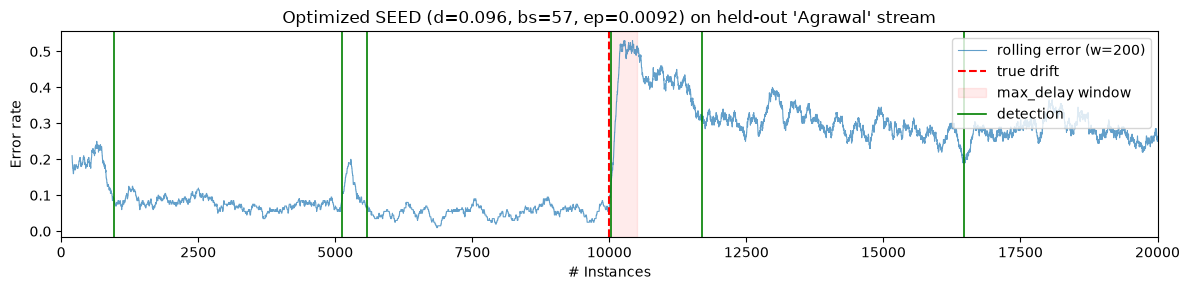

In [52]:
fig, ax = plt.subplots(figsize=(12, 3))

# Rolling error rate for visual context
window = 200
rolling_error = pd.Series(error_signals[held_out_name]).rolling(window).mean()
ax.plot(rolling_error, linewidth=0.8, alpha=0.7, label=f"rolling error (w={window})")

# True drift locations
for i, pos in enumerate(true_positions):
    ax.axvline(
        pos,
        color="red",
        linestyle="--",
        linewidth=1.5,
        label="true drift" if i == 0 else None,
    )
    ax.axvspan(
        pos,
        pos + MAX_DELAY,
        color="red",
        alpha=0.08,
        label="max_delay window" if i == 0 else None,
    )

# Detections
for i, det in enumerate(detections):
    ax.axvline(
        det,
        color="green",
        linewidth=1.2,
        label="detection" if i == 0 else None,
    )

ax.set_xlim(0, MAX_INSTANCES)
ax.set_xlabel("# Instances")
ax.set_ylabel("Error rate")
ax.set_title(
    f"Optimized SEED (d={best_params['delta']:.3f}, bs={best_params['block_size']}, "
    f"ep={best_params['epsilon_prime']:.4f}) on held-out '{held_out_name}' stream"
)
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

## Summary

This notebook demonstrated a **leave-one-dataset-out** protocol for
optimizing drift detector hyperparameters:

1. We built four synthetic streams with known drift locations.
2. A Hoeffding Tree produced a binary error signal on each stream.
3. We used sklearn's `ParameterSampler` to randomly sample SEED
   configurations (`delta`, `block_size`, and `epsilon_prime`).
4. We evaluated each configuration using the F1 metric from
   `EvaluateDriftDetector`.
5. For each held-out dataset, we selected the best configuration from
   the remaining three and measured how well it transferred.

The protocol generalizes to any detector and any set of hyperparameters.
By evaluating on held-out data, the results give a more realistic
estimate of how the tuned detector will perform on new streams.